Retrieve ensemble data and metadata.

In [ ]:
import os, json, torch, sys
import numpy as np
import polars as pl
sys.path.append("..")

# Project imports
from utils import env
from utils import ensemble_utils as ens
from utils import run_inference as inf
import exp_diversity as exp

import matplotlib.pyplot as plt

# Configuration
save_dir = "../save/ensembles"
index = ens.load_index(save_dir)

results_list = []

for run_hash in index:
    run_names = index[run_hash]
    
    # Collect Component (Individual Model) Data
    comp_accs = []
    labels = None
    for rn in run_names:
        mod, tri = ens.parse_run_name(rn)
        inf_data = inf.get_or_run_inference(mod, tri)
        comp_accs.append(inf_data['accuracy'])
        if labels is None:
            labels = inf_data['labels'] # Ensure labels are available for ensemble evaluation
            
    comp_accs = np.array(comp_accs)    
    
    # 2. Initialize the row with base stats
    row = {
        "hash": run_hash,
        "comp_mean_acc": comp_accs.mean(),
        "comp_max_acc": comp_accs.max(),
        "num_models": len(run_names)
    }

    # 3. Retrieve Ensemble Accuracies
    # load_ensemble returns {method_name: probabilities_tensor}
    ensemble_outputs = ens.load_ensemble(save_dir, run_hash)
    for method, probs in ensemble_outputs.items():
        preds = probs.argmax(dim=1)
        # Compare ensemble predictions against ground truth labels
        acc = float((preds == labels).float().mean().item())
        row[f"ens_acc_{method}"] = acc
        md = ens.load_metadata(save_dir, run_hash)
        row["rho"] = md.get('rho', None)
        row["name"] = md.get('name', None)
        

    # 4. Retrieve Diversity Metrics (from diversity.csv)
    # get_diversity_results returns (scalar_dict, pairwise_dict)
    div_scalars, _ = exp.get_diversity_results(run_hash, save_dir)
    row.update(div_scalars)

    results_list.append(row)

# Create Polars DataFrame
ens_df = pl.DataFrame(results_list)

print(f"Collected data for {len(ens_df)} ensembles.")

# # Drop columns that have any null values
# df = df[[s.name for s in df if s.null_count() == 0]]

display(ens_df)

Collected data for 8 ensembles.


hash,comp_mean_acc,comp_max_acc,num_models,ens_acc_soft,rho,name,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic
str,f64,f64,i64,f64,f64,str,f64,f64,f64,f64,f64
"""a1e45672b95b068f""",0.91316,0.9163,5,0.9383,0.0,"""CE_rho0""",0.9357,0.9387,0.936,0.09459,0.922607
"""d171a509f132433f""",0.91068,0.9164,5,0.9392,0.2,"""CE_rho0.2""",0.9365,0.9381,0.9376,0.09944,0.915967
"""bd42f16b6bed4d1f""",0.9141,0.9165,5,0.9396,0.04,"""CE_rho0.04""",0.936,0.9394,0.9374,0.09246,0.924856
"""b042086518e6c16f""",0.91088,0.9185,5,0.9366,0.008,"""CE_rho0.008""",0.9344,0.937,0.9344,0.09663,0.922914
"""cd8c55c69a4f2949""",0.912367,0.9165,3,0.9332,0.0,"""crossentropy_wstopo_grid_256em…",0.93,0.9335,0.9294,0.092467,0.930434
"""b7ff5a1bb36b11b9""",0.912033,0.9153,3,0.9319,0.2,"""crossentropy_wstopo_grid_256em…",0.9315,0.9304,0.93,0.0953,0.920959
"""a46149a6897d5767""",0.912833,0.916,3,0.9327,0.04,"""crossentropy_wstopo_grid_256em…",0.9325,0.9332,0.9287,0.090633,0.931975
"""664d92e5ca1187b1""",0.9094,0.9163,3,0.9323,0.008,"""crossentropy_wstopo_grid_256em…",0.9298,0.9321,0.927,0.096633,0.924407


Add a column with increase in performance over mean and max component


In [17]:
ens_gain_df = ens_df
ens_acc_cols = [col for col in ens_df.columns if col.startswith('ens_acc_')]
print(ens_acc_cols)

# Create gain columns dynamically for both mean and max
for acc_col in ens_acc_cols:
    # Extract method name (e.g., 'ens_acc_soft' -> 'soft')
    method = acc_col.replace('ens_acc_', '')
    
    # Add gain columns: ens_acc_method - comp_mean_acc and ens_acc_method - comp_max_acc
    ens_gain_df = ens_gain_df.with_columns([
        (pl.col(acc_col) - pl.col('comp_mean_acc')).alias(f'ens_gain_mean_{method}'),
        (pl.col(acc_col) - pl.col('comp_max_acc')).alias(f'ens_gain_max_{method}')
    ])

ens_gain_df

['ens_acc_soft', 'ens_acc_max_confidence', 'ens_acc_conf_weighted', 'ens_acc_hard']


hash,comp_mean_acc,comp_max_acc,num_models,ens_acc_soft,rho,name,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_max_soft,ens_gain_mean_max_confidence,ens_gain_max_max_confidence,ens_gain_mean_conf_weighted,ens_gain_max_conf_weighted,ens_gain_mean_hard,ens_gain_max_hard
str,f64,f64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""a1e45672b95b068f""",0.91316,0.9163,5,0.9383,0.0,"""CE_rho0""",0.9357,0.9387,0.936,0.09459,0.922607,0.02514,0.022,0.02254,0.0194,0.02554,0.0224,0.02284,0.0197
"""d171a509f132433f""",0.91068,0.9164,5,0.9392,0.2,"""CE_rho0.2""",0.9365,0.9381,0.9376,0.09944,0.915967,0.02852,0.0228,0.02582,0.0201,0.02742,0.0217,0.02692,0.0212
"""bd42f16b6bed4d1f""",0.9141,0.9165,5,0.9396,0.04,"""CE_rho0.04""",0.936,0.9394,0.9374,0.09246,0.924856,0.0255,0.0231,0.0219,0.0195,0.0253,0.0229,0.0233,0.0209
"""b042086518e6c16f""",0.91088,0.9185,5,0.9366,0.008,"""CE_rho0.008""",0.9344,0.937,0.9344,0.09663,0.922914,0.02572,0.0181,0.02352,0.0159,0.02612,0.0185,0.02352,0.0159
"""cd8c55c69a4f2949""",0.912367,0.9165,3,0.9332,0.0,"""crossentropy_wstopo_grid_256em…",0.93,0.9335,0.9294,0.092467,0.930434,0.020833,0.0167,0.017633,0.0135,0.021133,0.017,0.017033,0.0129
"""b7ff5a1bb36b11b9""",0.912033,0.9153,3,0.9319,0.2,"""crossentropy_wstopo_grid_256em…",0.9315,0.9304,0.93,0.0953,0.920959,0.019867,0.0166,0.019467,0.0162,0.018367,0.0151,0.017967,0.0147
"""a46149a6897d5767""",0.912833,0.916,3,0.9327,0.04,"""crossentropy_wstopo_grid_256em…",0.9325,0.9332,0.9287,0.090633,0.931975,0.019867,0.0167,0.019667,0.0165,0.020367,0.0172,0.015867,0.0127
"""664d92e5ca1187b1""",0.9094,0.9163,3,0.9323,0.008,"""crossentropy_wstopo_grid_256em…",0.9298,0.9321,0.927,0.096633,0.924407,0.0229,0.016,0.0204,0.0135,0.0227,0.0158,0.0176,0.0107


Retrieve consistency data and join it with previous

In [18]:
cons_df = pl.read_csv('../save/ResNet18/models/RSA_consistency.csv')
cons_df = cons_df.rename({'mean': 'consistency'})
cons_df = cons_df.join(ens_gain_df, left_on="model", right_on="name")
# Drop comparison vs max
max_comp = [col for col in cons_df.columns if col.startswith('ens_gain_max_')]
cons_df = cons_df.drop(['model', 'hash', 'std', 'num_pairs', 'message', 'comp_max_acc','num_trials'])
cons_df = cons_df.drop(max_comp)
cons_df

consistency,comp_mean_acc,num_models,ens_acc_soft,rho,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.830751,0.91316,5,0.9383,0.0,0.9357,0.9387,0.936,0.09459,0.922607,0.02514,0.02254,0.02554,0.02284
0.829816,0.91088,5,0.9366,0.008,0.9344,0.937,0.9344,0.09663,0.922914,0.02572,0.02352,0.02612,0.02352
0.730588,0.9141,5,0.9396,0.04,0.936,0.9394,0.9374,0.09246,0.924856,0.0255,0.0219,0.0253,0.0233
0.611853,0.91068,5,0.9392,0.2,0.9365,0.9381,0.9376,0.09944,0.915967,0.02852,0.02582,0.02742,0.02692
0.83229,0.912367,3,0.9332,0.0,0.93,0.9335,0.9294,0.092467,0.930434,0.020833,0.017633,0.021133,0.017033
0.846644,0.9094,3,0.9323,0.008,0.9298,0.9321,0.927,0.096633,0.924407,0.0229,0.0204,0.0227,0.0176
0.704973,0.912833,3,0.9327,0.04,0.9325,0.9332,0.9287,0.090633,0.931975,0.019867,0.019667,0.020367,0.015867
0.614848,0.912033,3,0.9319,0.2,0.9315,0.9304,0.93,0.0953,0.920959,0.019867,0.019467,0.018367,0.017967


Make q statistic opposite and bounded between 0 and 1 so that it is directionally consistent with the other metrics.

In [19]:
# cons_df = cons_df.with_columns(
#     trans_q_statistic = pl.col("q_statistic")/2+0.5
# ).filter(pl.col("rho").is_not_null())
# cons_df
# # cons_df = cons_df['model', 'rho','mean', 'num_trials']

In [20]:
display(cons_df.corr())

consistency,comp_mean_acc,num_models,ens_acc_soft,rho,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,-0.110635,0.005734,-0.07123,-0.930314,-0.288718,0.103077,-0.218166,-0.182767,0.427789,-0.020664,-0.235862,0.162086,-0.189698
-0.110635,1.0,0.191459,0.305679,-0.146744,0.350591,0.349483,0.340049,-0.736888,0.366754,-0.16359,-0.220756,-0.105265,-0.020319
0.005734,0.191459,1.0,0.957896,0.0,0.92603,0.942809,0.952854,0.379335,-0.561274,0.900538,0.852225,0.909498,0.939918
-0.07123,0.305679,0.957896,1.0,0.033846,0.933262,0.975309,0.972444,0.279647,-0.499514,0.889302,0.792838,0.889602,0.917132
-0.930314,-0.146744,0.0,0.033846,1.0,0.204642,-0.170572,0.195587,0.470044,-0.645634,0.105551,0.299094,-0.111161,0.263971
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.427789,0.366754,-0.561274,-0.499514,-0.645634,-0.531441,-0.33165,-0.584647,-0.883793,1.0,-0.693714,-0.76833,-0.526651,-0.761609
-0.020664,-0.16359,0.900538,0.889302,0.105551,0.798581,0.84268,0.844243,0.643684,-0.693714,1.0,0.927509,0.972297,0.960021
-0.235862,-0.220756,0.852225,0.792838,0.299094,0.836029,0.725445,0.795263,0.696525,-0.76833,0.927509,1.0,0.87509,0.929776


Now write a function for finding correlation

In [21]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

def scatter_and_corr(
    df: pl.DataFrame, 
    col_x: str, 
    col_ys: list[str],
    y_labels: list[str] = None,
    # xscale: str = "log",
    xlabel: str = None,
    title: str = None,
    colors: list = None
):
    """Plot col_x vs a list of col_ys, with correlations for each."""
    plt.figure(figsize=(9, 6))
    results = []  # For correlations

    if y_labels is None:
        y_labels = col_ys
    if colors is None:
        from matplotlib.cm import get_cmap
        cm = get_cmap("tab10")
        colors = [cm(i) for i in range(len(col_ys))]

    # Plot each y
    for idx, (col_y, label, color) in enumerate(zip(col_ys, y_labels, colors)):
        x = df[col_x].to_numpy()
        y = df[col_y].to_numpy()
        plt.scatter(x, y, label=label, alpha=0.7, s=80, color=color)

        # Compute correlations
        pearson = df.select(pl.corr(col_x, col_y, method='pearson')).item()
        spearman = df.select(pl.corr(col_x, col_y, method='spearman')).item()
        results.append((label, pearson, spearman))

    plt.xlabel(xlabel or col_x, fontsize=13)
    plt.ylabel(" / ".join(y_labels), fontsize=13)
    # if xscale: plt.xscale(xscale)
    if title:
        plt.title(title, fontsize=15)
    else:
        plt.title(f"{col_x} vs {'/'.join(y_labels)}")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print correlations
    for label, pearson, spearman in results:
        print(f"- {label}:")
        print(f"   Pearson r: {pearson:.3f}")
        print(f"   Spearman 𝜌: {spearman:.3f}")

In [22]:
display(cons_df)

consistency,comp_mean_acc,num_models,ens_acc_soft,rho,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.830751,0.91316,5,0.9383,0.0,0.9357,0.9387,0.936,0.09459,0.922607,0.02514,0.02254,0.02554,0.02284
0.829816,0.91088,5,0.9366,0.008,0.9344,0.937,0.9344,0.09663,0.922914,0.02572,0.02352,0.02612,0.02352
0.730588,0.9141,5,0.9396,0.04,0.936,0.9394,0.9374,0.09246,0.924856,0.0255,0.0219,0.0253,0.0233
0.611853,0.91068,5,0.9392,0.2,0.9365,0.9381,0.9376,0.09944,0.915967,0.02852,0.02582,0.02742,0.02692
0.83229,0.912367,3,0.9332,0.0,0.93,0.9335,0.9294,0.092467,0.930434,0.020833,0.017633,0.021133,0.017033
0.846644,0.9094,3,0.9323,0.008,0.9298,0.9321,0.927,0.096633,0.924407,0.0229,0.0204,0.0227,0.0176
0.704973,0.912833,3,0.9327,0.04,0.9325,0.9332,0.9287,0.090633,0.931975,0.019867,0.019667,0.020367,0.015867
0.614848,0.912033,3,0.9319,0.2,0.9315,0.9304,0.93,0.0953,0.920959,0.019867,0.019467,0.018367,0.017967


And we use it on some combinations. First rho and consistency.

/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


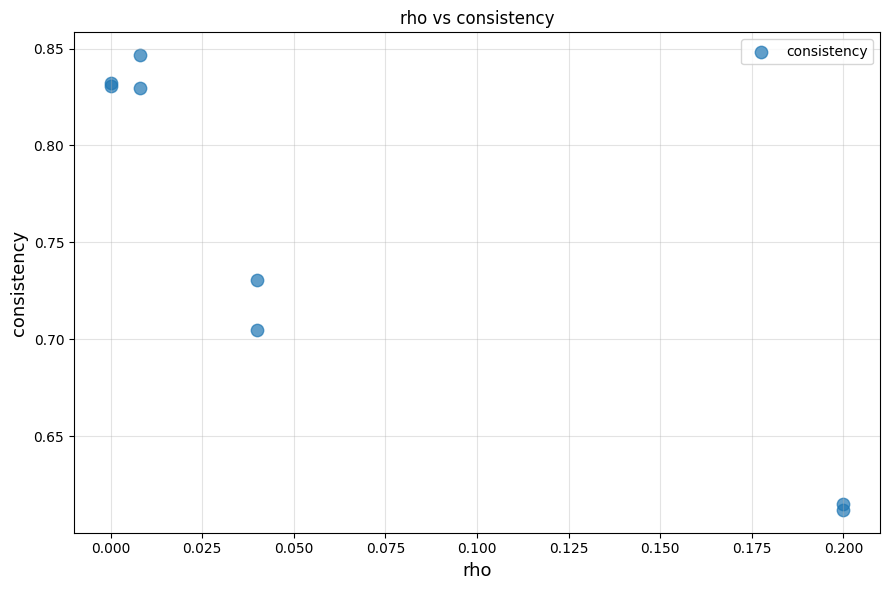

- consistency:
   Pearson r: -0.930
   Spearman 𝜌: -0.878


In [23]:
scatter_and_corr(cons_df, 'rho', ['consistency'])

Proves the results of previous paper.
Next, rho and diversity


['consistency', 'comp_mean_acc', 'num_models', 'ens_acc_soft', 'rho', 'ens_acc_max_confidence', 'ens_acc_conf_weighted', 'ens_acc_hard', 'pred_disagreement', 'q_statistic', 'ens_gain_mean_soft', 'ens_gain_mean_max_confidence', 'ens_gain_mean_conf_weighted', 'ens_gain_mean_hard']


/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


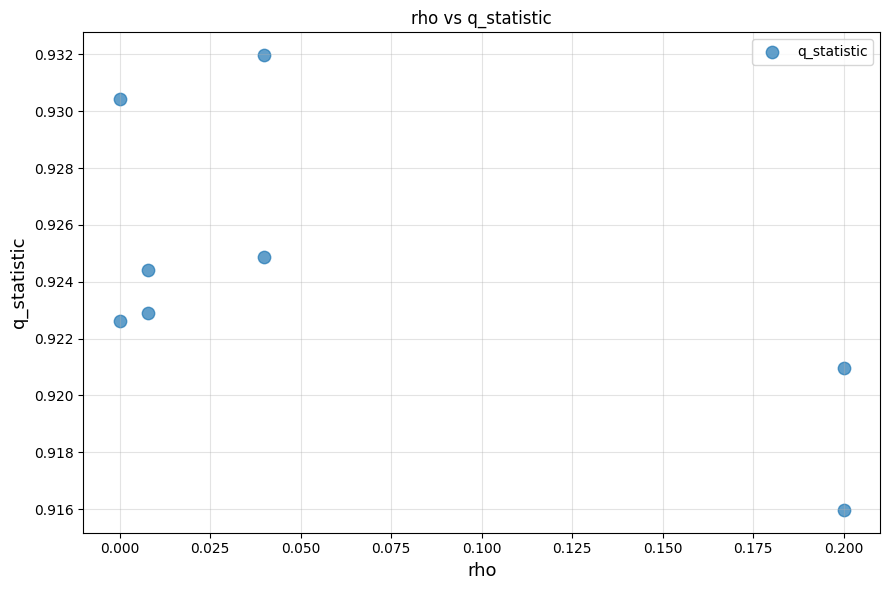

- q_statistic:
   Pearson r: -0.646
   Spearman 𝜌: -0.390


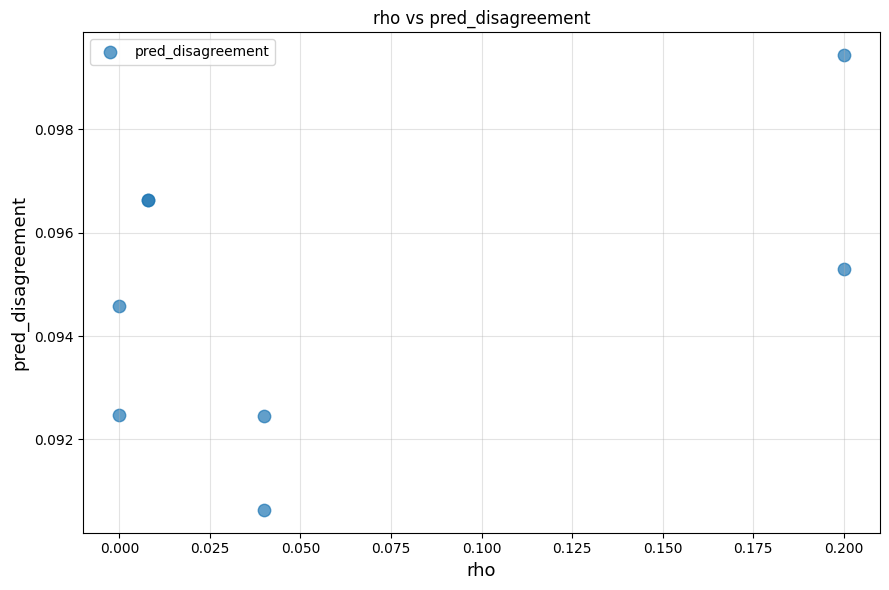

- pred_disagreement:
   Pearson r: 0.470
   Spearman 𝜌: 0.195


In [24]:
print(cons_df.columns)
scatter_and_corr(cons_df, 'rho', ['q_statistic'])
scatter_and_corr(cons_df, 'rho', ['pred_disagreement'])


/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


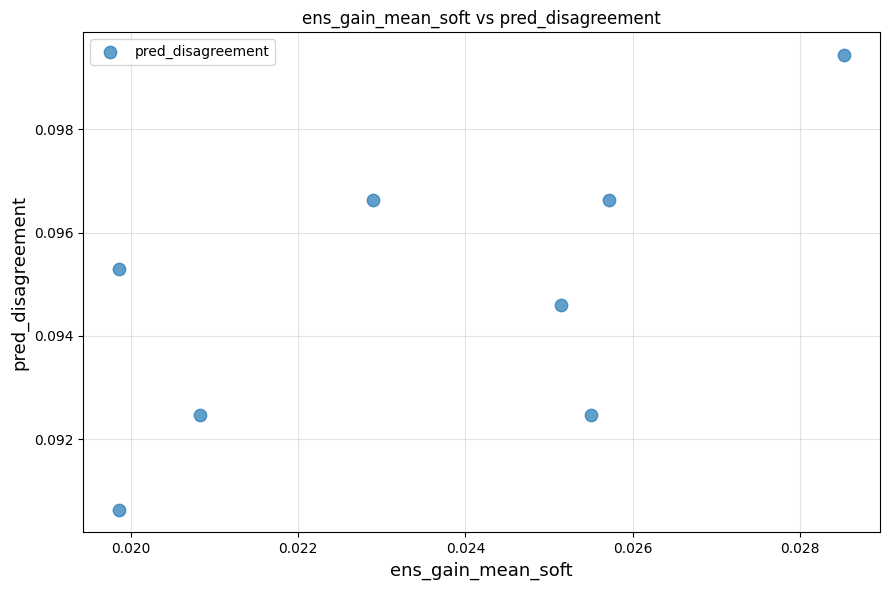

- pred_disagreement:
   Pearson r: 0.644
   Spearman 𝜌: 0.571


In [25]:
scatter_and_corr(cons_df, 'ens_gain_mean_soft', ['pred_disagreement'])


/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


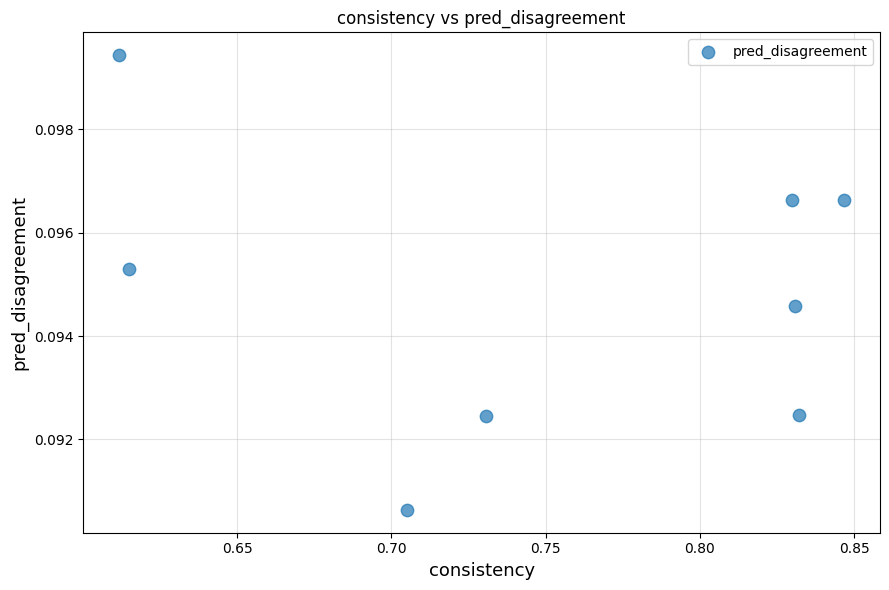

- pred_disagreement:
   Pearson r: -0.183
   Spearman 𝜌: -0.048


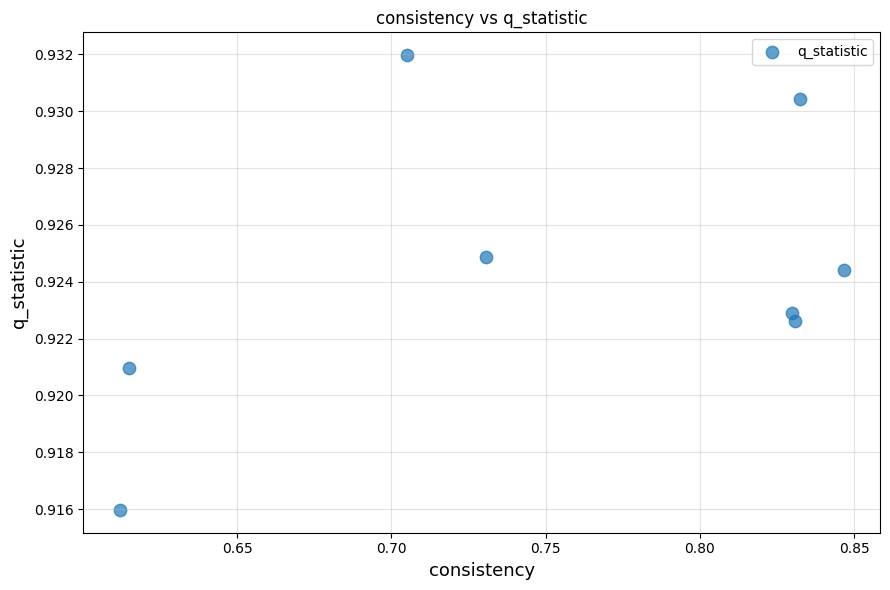

- q_statistic:
   Pearson r: 0.428
   Spearman 𝜌: 0.429


In [26]:
scatter_and_corr(cons_df, 'consistency', ['pred_disagreement'])
scatter_and_corr(cons_df, 'consistency', ['q_statistic'])


/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


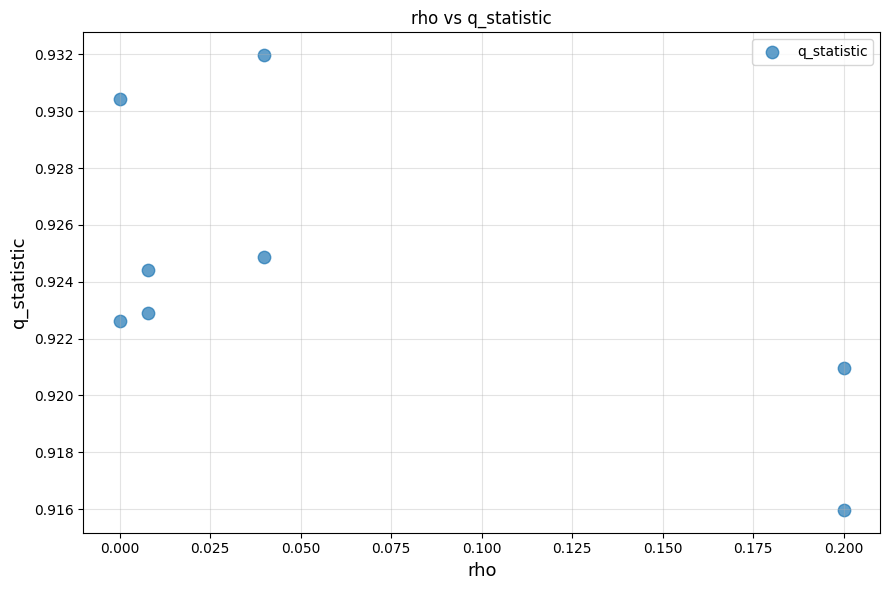

- q_statistic:
   Pearson r: -0.646
   Spearman 𝜌: -0.390


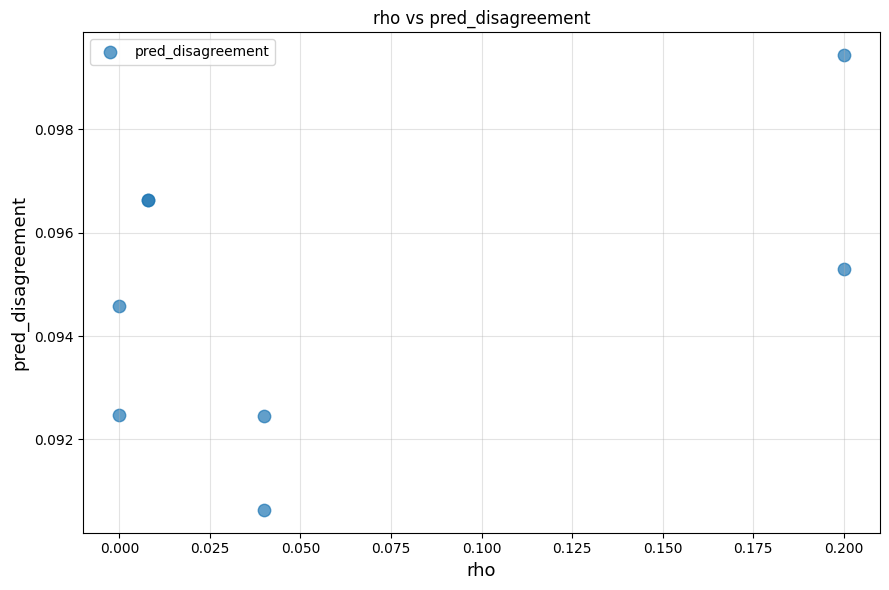

- pred_disagreement:
   Pearson r: 0.470
   Spearman 𝜌: 0.195


In [27]:
scatter_and_corr(cons_df, 'rho', ['q_statistic'])
scatter_and_corr(cons_df, 'rho', ['pred_disagreement'])


/tmp/ipykernel_140471/3304035630.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap("tab10")


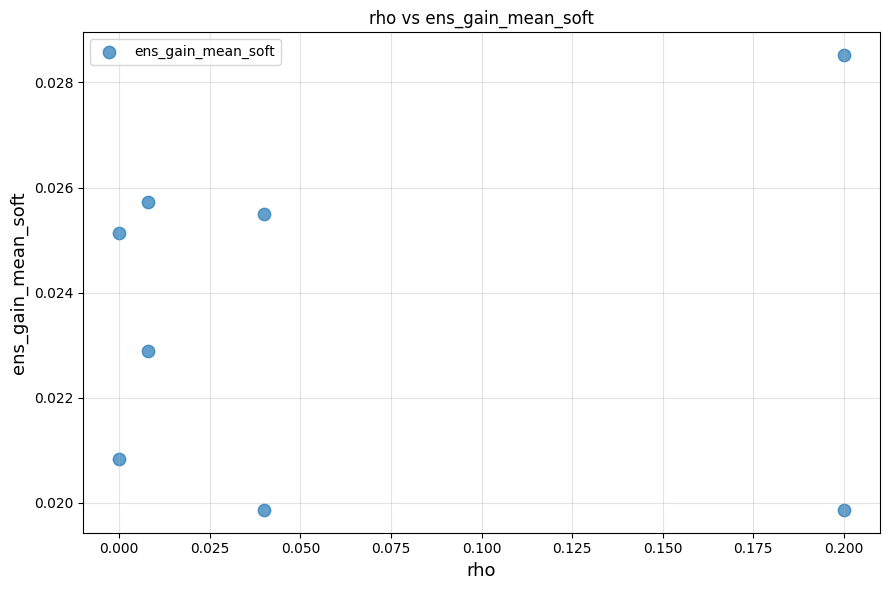

- ens_gain_mean_soft:
   Pearson r: 0.106
   Spearman 𝜌: 0.049


In [28]:
scatter_and_corr(cons_df, 'rho', ['ens_gain_mean_soft'])

consistency,comp_mean_acc,num_models,ens_acc_soft,rho,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.611853,0.91068,5,0.9392,0.2,0.9365,0.9381,0.9376,0.09944,0.915967,0.02852,0.02582,0.02742,0.02692
0.614848,0.912033,3,0.9319,0.2,0.9315,0.9304,0.93,0.0953,0.920959,0.019867,0.019467,0.018367,0.017967
0.830751,0.91316,5,0.9383,0.0,0.9357,0.9387,0.936,0.09459,0.922607,0.02514,0.02254,0.02554,0.02284
0.829816,0.91088,5,0.9366,0.008,0.9344,0.937,0.9344,0.09663,0.922914,0.02572,0.02352,0.02612,0.02352
0.846644,0.9094,3,0.9323,0.008,0.9298,0.9321,0.927,0.096633,0.924407,0.0229,0.0204,0.0227,0.0176
0.730588,0.9141,5,0.9396,0.04,0.936,0.9394,0.9374,0.09246,0.924856,0.0255,0.0219,0.0253,0.0233
0.83229,0.912367,3,0.9332,0.0,0.93,0.9335,0.9294,0.092467,0.930434,0.020833,0.017633,0.021133,0.017033
0.704973,0.912833,3,0.9327,0.04,0.9325,0.9332,0.9287,0.090633,0.931975,0.019867,0.019667,0.020367,0.015867


Text(0, 0.5, 'Ensemble performance gain')

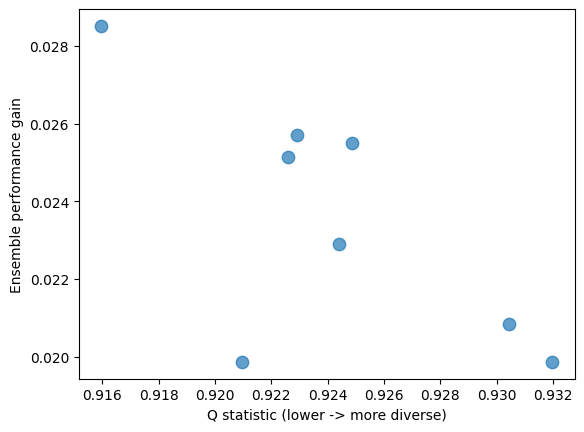

In [29]:
display(cons_df.sort(by='q_statistic'))

plt.scatter(cons_df['q_statistic'], cons_df['ens_gain_mean_soft'], alpha=0.7, s=80)
plt.xlabel("Q statistic (lower -> more diverse)")
plt.ylabel("Ensemble performance gain")

consistency,comp_mean_acc,num_models,ens_acc_soft,rho,ens_acc_max_confidence,ens_acc_conf_weighted,ens_acc_hard,pred_disagreement,q_statistic,ens_gain_mean_soft,ens_gain_mean_max_confidence,ens_gain_mean_conf_weighted,ens_gain_mean_hard
f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.611853,0.91068,5,0.9392,0.2,0.9365,0.9381,0.9376,0.09944,0.915967,0.02852,0.02582,0.02742,0.02692
0.614848,0.912033,3,0.9319,0.2,0.9315,0.9304,0.93,0.0953,0.920959,0.019867,0.019467,0.018367,0.017967
0.830751,0.91316,5,0.9383,0.0,0.9357,0.9387,0.936,0.09459,0.922607,0.02514,0.02254,0.02554,0.02284
0.829816,0.91088,5,0.9366,0.008,0.9344,0.937,0.9344,0.09663,0.922914,0.02572,0.02352,0.02612,0.02352
0.846644,0.9094,3,0.9323,0.008,0.9298,0.9321,0.927,0.096633,0.924407,0.0229,0.0204,0.0227,0.0176
0.730588,0.9141,5,0.9396,0.04,0.936,0.9394,0.9374,0.09246,0.924856,0.0255,0.0219,0.0253,0.0233
0.83229,0.912367,3,0.9332,0.0,0.93,0.9335,0.9294,0.092467,0.930434,0.020833,0.017633,0.021133,0.017033
0.704973,0.912833,3,0.9327,0.04,0.9325,0.9332,0.9287,0.090633,0.931975,0.019867,0.019667,0.020367,0.015867


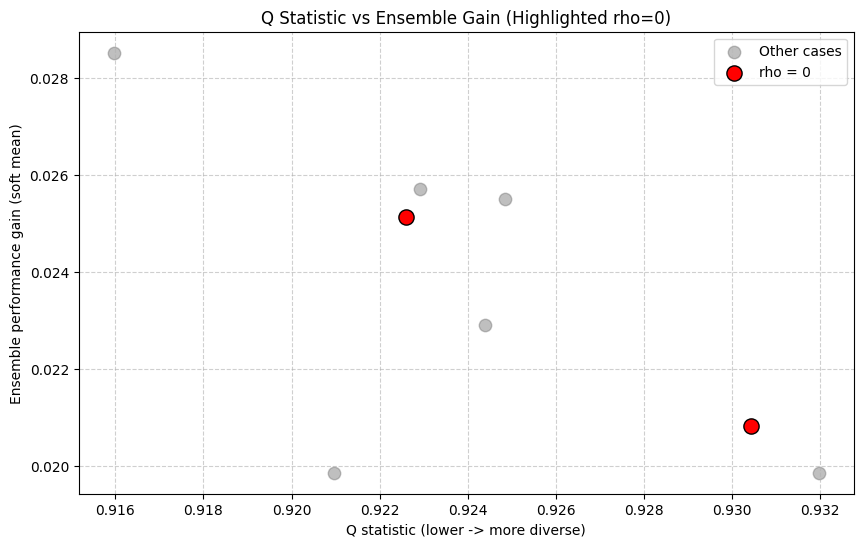

In [30]:
# 1. Sort and display the DataFrame
sorted_df = cons_df.sort(by='q_statistic')
display(sorted_df)
# 2. Plot all points
plt.figure(figsize=(10, 6))
plt.scatter(cons_df['q_statistic'], cons_df['ens_gain_mean_soft'], 
            alpha=0.5, s=80, label='Other cases', color='gray')
# 3. Highlight all cases where rho = 0
rho_zero = cons_df.filter(pl.col('rho') == 0)
plt.scatter(rho_zero['q_statistic'], rho_zero['ens_gain_mean_soft'], 
            color='red', s=120, edgecolors='black', label='rho = 0', zorder=3)
plt.xlabel("Q statistic (lower -> more diverse)")
plt.ylabel("Ensemble performance gain (soft mean)")
plt.title("Q Statistic vs Ensemble Gain (Highlighted rho=0)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()